# Samuel Meaux Modeling Portion (Class Imbalance Handling)

## Imports

In [1]:
import pandas as pd

import numpy as np

import os

from imblearn.under_sampling import RandomUnderSampler

from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LassoCV

from mlxtend.frequent_patterns import apriori, association_rules

from google.cloud import bigquery

import matplotlib.pyplot as plt



/Users/sawyermckenney/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sawyermckenney/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Install Google Cloud BigQuery if needed for API call

In [2]:
# !pip install --upgrade google-cloud-bigquery pandas-gbq

## Load in .JSON and call large data set into data frame (AI Generated)

In [6]:
key_path = "../../../fraud-detection-key.json"

if os.path.exists(key_path):
    client = bigquery.Client.from_service_account_json(key_path)
    
    # Using the 'CSCI' dataset and 'fraud_data' table found by your scout script
    query = """
        SELECT * FROM `csci-4022.CSCI.fraud_data`
    """
    
    print("🚀 Fetching the FULL dataset. This may take a moment...")
    
    # This pulls the entire table into a pandas DataFrame
    df = client.query(query).to_dataframe()
    
    print(f"✅ Success! Loaded {len(df):,} rows.")
    print(df.info()) # Shows column types and memory usage
else:
    print("❌ Key file not found.")

🚀 Fetching the FULL dataset. This may take a moment...
✅ Success! Loaded 999,999 rows.
<class 'pandas.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        999999 non-null  Int64  
 1   income                            999999 non-null  float64
 2   name_email_similarity             999999 non-null  float64
 3   prev_address_months_count         999999 non-null  Int64  
 4   current_address_months_count      999999 non-null  Int64  
 5   customer_age                      999999 non-null  Int64  
 6   days_since_request                999999 non-null  float64
 7   intended_balcon_amount            999999 non-null  float64
 8   payment_type                      999999 non-null  str    
 9   zip_count_4w                      999999 non-null  Int64  
 10  velocity_6h                       999999

## Cleaning and transforming the dataset. 
### In this section columns with known missing data is replaced with a Numpy NAN. The features and targets are split. X becomes all columns except the "answer key." y becomes the "answer key." Numerical columns with missing data are filled with the column mean. Numerical cells with missing data are filled with "-1." Categorical cells with missing data are filled with "unknown." Categorical columns are encoded.

In [4]:
# ==========================================
# CLEAN/TRANSFORM DATA (AI FIXED)
# ==========================================

# 1. Identify and Replace Missing Values in the main DF first
maybe_missing_cols = ["prev_address_months_count", "bank_months_count"]

for col in maybe_missing_cols:
    df[col] = df[col].replace(-1, np.nan)

# 2. Feature/Target Split (Do this BEFORE creating flags in X)
y = df["fraud_bool"]
X = df.drop(columns=["fraud_bool"])

# 3. CREATE FLAGS FIRST (Crucial Change)
# In your version, you tried to create flags on X before X was defined, 
# or after NaNs were already filled. They must be created while NaNs exist.
for col in maybe_missing_cols:
    X[f"{col}_is_missing"] = X[col].isna().astype(int)

# 4. Identify Column Types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# 5. Handle Numeric Columns
# Fill with median
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# 6. Handle Categorical Columns
X[cat_cols] = X[cat_cols].fillna("unknown")

# 7. Final Encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

print("Shape:", X.shape)
print("Missingness signals captured:", X["bank_months_count_is_missing"].sum())

Shape: (999999, 49)
Missingness signals captured: 253635


## Feature Selection
### The data is scaled, then the LassoCV function is used to identify non-significant features.

In [5]:
# =========================
# FEATURE SELECTION
# =========================


# 1. Scale your data (Lasso requires this!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit Lasso with Cross-Validation
# LassoCV automatically finds the best "penalty" strength
lasso = LassoCV(cv=15).fit(X_scaled, y)

# 3. See which features survived
important_features = X.columns[lasso.coef_ != 0]
deleted_features = X.columns[lasso.coef_ == 0]

print(f"Features to Keep: {list(important_features)}, {len(important_features)} total")
print(f"Features to Delete: {list(deleted_features)}")



Features to Keep: ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'month', 'prev_address_months_count_is_missing', 'bank_months_count_is_missing', 'payment_type_AB', 'payment_type_AC', 'payment_type_AE', 'employment_status_CB', 'employment_status_CC', 'employment_status_CD', 'employment_status_CE', 'employment_status_CF', 'employment_status_CG', 'housing_status_BB', 'housing_status_BC', 'housing_status_BD', 'housing_status_BE', 'housing_status_BF', 'housing_status_BG', 'source_TELEAPP', 'device_os_macintosh', 'devic

In [6]:
idx = X.columns.get_indexer(deleted_features)
print(f"Indices of Deleted Features: {list(idx)}")


Indices of Deleted Features: [np.int64(24), np.int64(30)]


## Feature Removal
### A final "X" is created with the features to keep

In [7]:
# =========================
# FEATURE REMOVAL
# =========================

# 1. Your target variable (y) comes from the original df
target_col = 'fraud_bool' 
y = df[target_col].values
X_final = X[important_features]

# 2. Your features (X) MUST come from the encoded object, NOT the original df
# Assuming 'X' is the variable you used for Lasso/Feature Selection
# X_final = X[list(important_features)].values

print(f"Final Feature Matrix X Shape: {X_final.shape}")
print(f"Final Target Vector y Shape: {y.shape}")


Final Feature Matrix X Shape: (999999, 47)
Final Target Vector y Shape: (999999,)


## Class Imbalance Handling
### Using undersampling, we randomly sample out 11,029 tuples from the full dataset that are classified as "not fraudulent." We end up with an evenly distributed data set of 11,029 tuples for each class for the creation of our models.

In [8]:
# =========================
# CLASS IMBALANCE HANDLING
# =========================

# AI Helped with RUS:
# setup of RandomUnderSampler
rus = RandomUnderSampler(random_state = 42)
X_resampled, y_resampled = rus.fit_resample(X_final, y)

print(f"Resampled class distribution:\n{pd.Series(y_resampled).value_counts()}")

Resampled class distribution:
0.0    11029
1.0    11029
Name: count, dtype: int64


## Splitting the Training and Test Data (80%/20%)

In [9]:
# =========================
# TRAINING/TESTING SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

## Model 1: Decision Tree
### The decision tree model gave us an accuracy of 72.46%, a precision of 73% (Fraud) a recall of 74% (Fraud), and F1-Score of 73% (Fraud)

In [10]:
# =========================
# DECISION TREE
# =========================

print("Running Decision Tree Model...")
clf = DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

Running Decision Tree Model...


DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42)

In [11]:
# EVALUATION

print("Evaluating Decision Tree Model...")
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Evaluating Decision Tree Model...
Accuracy: 0.7271078875793291
Confusion Matrix:
 [[1581  651]
 [ 553 1627]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.74      0.71      0.72      2232
         1.0       0.71      0.75      0.73      2180

    accuracy                           0.73      4412
   macro avg       0.73      0.73      0.73      4412
weighted avg       0.73      0.73      0.73      4412



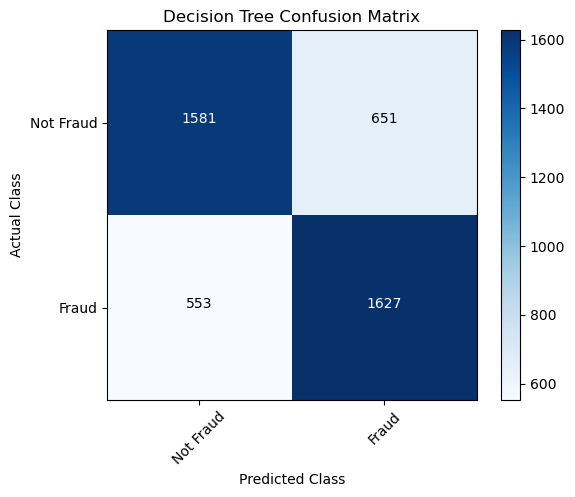

In [12]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Model 2: Support Vector Machine (SVM)
### The SVM model gave us an accuracy of 78.49%, a precision of 79% (Fraud) a recall of 78% (Fraud), and F1-Score of 78% (Fraud)

In [13]:
# =========================
# SUPPORT VECTOR MACHINE
# =========================

print("Running Support Vector Machine Model...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_clf = SVC(kernel='rbf',class_weight="balanced", probability = True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)


Running Support Vector Machine Model...


SVC(class_weight='balanced', probability=True, random_state=42)

In [14]:
# EVALUATION
print("Evaluating Support Vector Machine Model...")
y_pred_svm = svm_clf.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))


Evaluating Support Vector Machine Model...
Accuracy: 0.7896645512239348
Confusion Matrix:
 [[1763  469]
 [ 459 1721]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.79      0.79      2232
         1.0       0.79      0.79      0.79      2180

    accuracy                           0.79      4412
   macro avg       0.79      0.79      0.79      4412
weighted avg       0.79      0.79      0.79      4412



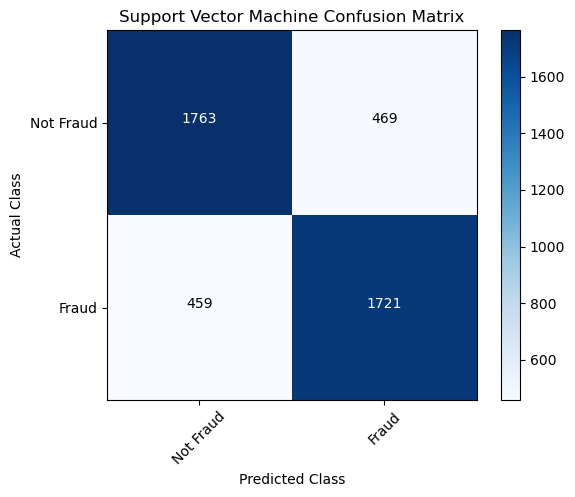

In [15]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred_svm)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Support Vector Machine Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Model 3: Apriori
### Not a predictive model, Apriori was conducted only with a small subset of features (income, credit_risk_score, phone_home_valid, and has_other_cards). This model shows us that most significant predictors for fraud were high credit risk and high income.

In [16]:
# =========================
# APRIORI
# =========================

selected_features = ["income", "credit_risk_score", "phone_home_valid", "has_other_cards"]
X_apriori = X_test[selected_features].copy()
X_apriori['fraud_bool'] = y_test

print("Running Apriori Algorithm...")
X_apriori["income_bin"] = pd.qcut(X_apriori["income"], 3, labels=["low_inc", "mid_inc", "high_inc"])
X_apriori["credit_bin"] = pd.qcut(X_apriori["credit_risk_score"], 3, labels=["low_risk", "mid_risk", "high_risk"])
X_apriori = X_apriori.drop(columns=["income", "credit_risk_score"])
X_encoded = pd.get_dummies(X_apriori, columns=["income_bin", "credit_bin"])
X_encoded = X_encoded.astype(bool)
frequent_itemsets = apriori(X_encoded, min_support=0.01, use_colnames=True, max_len=3)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
fraud_rules = rules[rules['consequents'].apply(lambda x: 'fraud_bool' in str(x))]
print("\n=== TOP FRAUD RULES ===")
print(fraud_rules.sort_values("lift", ascending=False).head(10))


Running Apriori Algorithm...

=== TOP FRAUD RULES ===
                                    antecedents  \
69                       (credit_bin_high_risk)   
47                       (credit_bin_high_risk)   
70                        (income_bin_high_inc)   
66  (credit_bin_high_risk, income_bin_high_inc)   
45                        (income_bin_high_inc)   
4                        (credit_bin_high_risk)   
2                         (income_bin_high_inc)   
35                       (credit_bin_high_risk)   
62                       (credit_bin_high_risk)   
33                        (income_bin_high_inc)   

                           consequents  antecedent support  \
69   (income_bin_high_inc, fraud_bool)            0.329102   
47       (has_other_cards, fraud_bool)            0.329102   
70  (credit_bin_high_risk, fraud_bool)            0.325023   
66                        (fraud_bool)            0.148005   
45       (has_other_cards, fraud_bool)            0.325023   
4           

## Model 4: Ensemble (Decision Tree and Support Vector Machine)
### The Ensemble model gave us an accuracy of 76.84%, a precision of 76% (Fraud) a recall of 77% (Fraud), and F1-Score of 77% (Fraud)

In [17]:
# Ensemble Model

ensemble_clf = VotingClassifier(estimators=[
    ('svc', svm_clf),
    ('dt', clf)
], voting='soft')
print("Running Ensemble Model...")
ensemble_clf.fit(X_train_scaled, y_train)
y_pred_ensemble = ensemble_clf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_ensemble)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))
print("Classification Report:\n", classification_report(y_test, y_pred_ensemble))

Running Ensemble Model...
Accuracy: 0.7722121486854034
Confusion Matrix:
 [[1704  528]
 [ 477 1703]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.76      0.77      2232
         1.0       0.76      0.78      0.77      2180

    accuracy                           0.77      4412
   macro avg       0.77      0.77      0.77      4412
weighted avg       0.77      0.77      0.77      4412



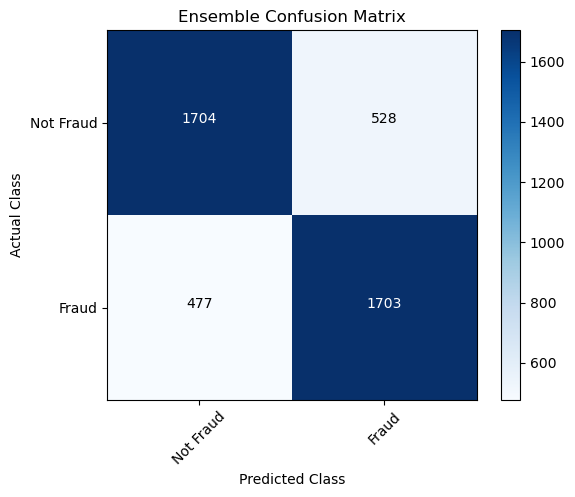

In [18]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred_ensemble)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Ensemble Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Model 5: Stacking (Decision Tree and Support Vector Machine)
### The Stacking model gave us an accuracy of 78.65%, a precision of 78% (Fraud) a recall of 78% (Fraud), and F1-Score of 78% (Fraud)

In [19]:
# Stacking Model
print("Running Stacking Model...")
stacking_model = StackingClassifier(estimators=[
    ('svc', svm_clf),
    ('dt', clf)
], final_estimator=LogisticRegression())

stacking_model.fit(X_train_scaled, y_train)
y_pred_stacking = stacking_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_stacking)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_stacking))
print("Classification Report:\n", classification_report(y_test, y_pred_stacking))


Running Stacking Model...
Accuracy: 0.7896645512239348
Confusion Matrix:
 [[1768  464]
 [ 464 1716]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.79      0.79      2232
         1.0       0.79      0.79      0.79      2180

    accuracy                           0.79      4412
   macro avg       0.79      0.79      0.79      4412
weighted avg       0.79      0.79      0.79      4412



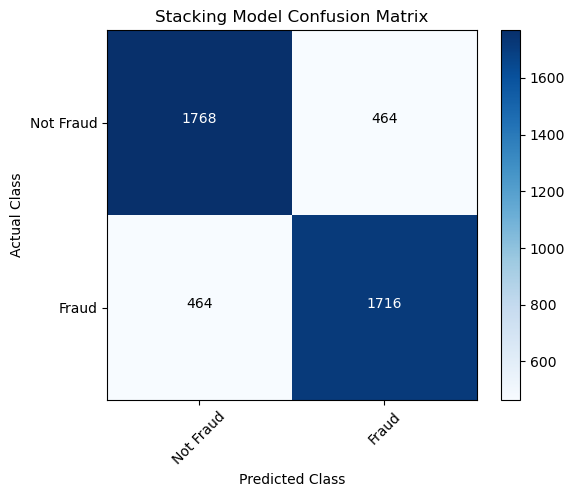

In [20]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred_stacking)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Stacking Model Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Model 6: Random Forest Model
### The Random Forest model gave us an accuracy of 78.05%, a precision of 78% (Fraud) a recall of 77% (Fraud), and F1-Score of 78% (Fraud)

In [21]:
# Random Forest Model
print("Running Random Forest Model...")
rfmodel = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rfmodel.fit(X_train_scaled, y_train)
y_pred_rf = rfmodel.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Running Random Forest Model...
Accuracy: 0.7878513145965549
Confusion Matrix:
 [[1772  460]
 [ 476 1704]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.79      0.79      2232
         1.0       0.79      0.78      0.78      2180

    accuracy                           0.79      4412
   macro avg       0.79      0.79      0.79      4412
weighted avg       0.79      0.79      0.79      4412



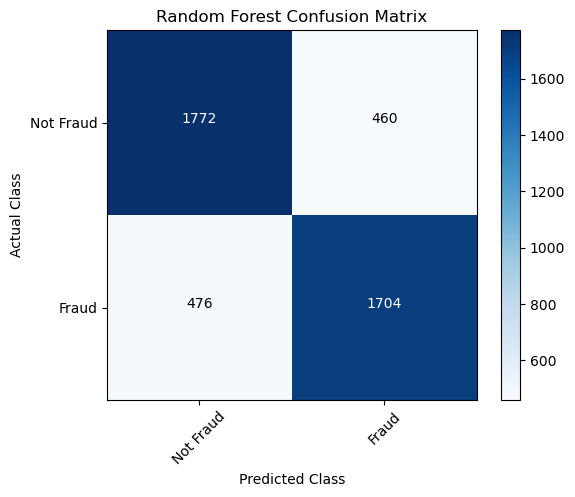

In [22]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred_rf)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Random Forest Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Model 7: Scaled Boosting Model
### The Scaled Boosting Model gave us an accuracy of 79.05%, a precision of 79% (Fraud) a recall of 78% (Fraud), and F1-Score of 79% (Fraud)

In [23]:
# Boosting Model Scaled
print("Running Gradient Scaled Boosting Model...")
gradient_boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gradient_boosting_model.fit(X_train_scaled, y_train)
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_gradient_boosting)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gradient_boosting))
print("Classification Report:\n", classification_report(y_test, y_pred_gradient_boosting))

Running Gradient Scaled Boosting Model...
Accuracy: 0.793064369900272
Confusion Matrix:
 [[1785  447]
 [ 466 1714]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.80      0.80      2232
         1.0       0.79      0.79      0.79      2180

    accuracy                           0.79      4412
   macro avg       0.79      0.79      0.79      4412
weighted avg       0.79      0.79      0.79      4412



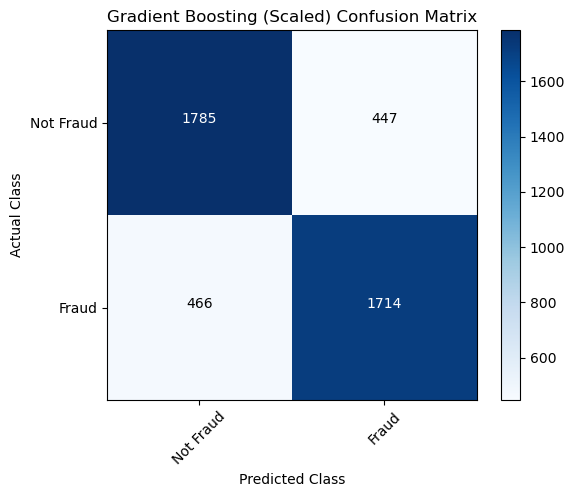

In [24]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred_gradient_boosting)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Gradient Boosting (Scaled) Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Model 8: Unscaled Boosting Model
### The Unscaled Boosting Model gave us an accuracy of 79.05%, a precision of 79% (Fraud) a recall of 78% (Fraud), and F1-Score of 79% (Fraud)

In [25]:
# Boosting Model Unscaled
print("Running Unscaled Gradient Boosting Model...")
gradient_boosting_model_unscaled = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gradient_boosting_model_unscaled.fit(X_train, y_train)
y_pred_gradient_boosting_unscaled = gradient_boosting_model_unscaled.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_gradient_boosting_unscaled)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gradient_boosting_unscaled))
print("Classification Report:\n", classification_report(y_test, y_pred_gradient_boosting_unscaled))

Running Unscaled Gradient Boosting Model...
Accuracy: 0.793064369900272
Confusion Matrix:
 [[1785  447]
 [ 466 1714]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.80      0.80      2232
         1.0       0.79      0.79      0.79      2180

    accuracy                           0.79      4412
   macro avg       0.79      0.79      0.79      4412
weighted avg       0.79      0.79      0.79      4412



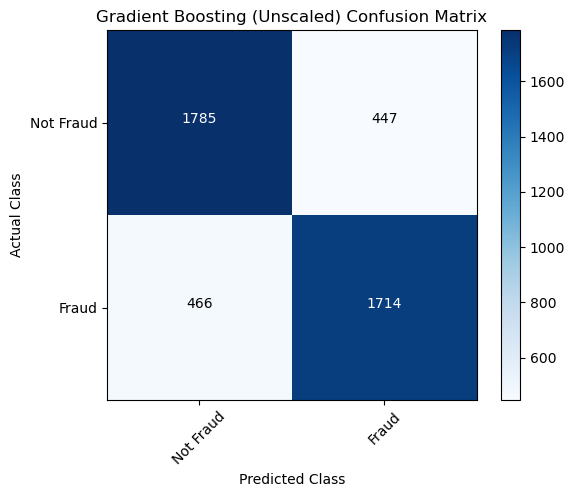

In [26]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y_test, y_pred_gradient_boosting_unscaled)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Gradient Boosting (Unscaled) Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

# Full Data Set Testing
### I only decided to run full models on Decision Tree, Support Vector Machine, Ensemble and Stacking becuase these four models were trained on a balanced data set using undersampling. The other three models are not related to class imbalance handling and are addressed in other portions of the project.

## Decision Tree Model

In [27]:
print("Evaluating Decision Tree Model...")
y_pred_full = clf.predict(X_final)
# ==========================================
# 4. FINAL STATUS REPORT
# ==========================================
print("\n" + "="*40)
print("FINAL EVALUATION: FULL IMBALANCED DATASET")
print("="*40)
print(f"Accuracy: {accuracy_score(y, y_pred_full):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_full))
print("\nClassification Report:")
print(classification_report(y, y_pred_full))

Evaluating Decision Tree Model...

FINAL EVALUATION: FULL IMBALANCED DATASET
Accuracy: 0.7280

Confusion Matrix:
[[718911 270059]
 [  1896   9133]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.73      0.84    988970
         1.0       0.03      0.83      0.06     11029

    accuracy                           0.73    999999
   macro avg       0.52      0.78      0.45    999999
weighted avg       0.99      0.73      0.83    999999



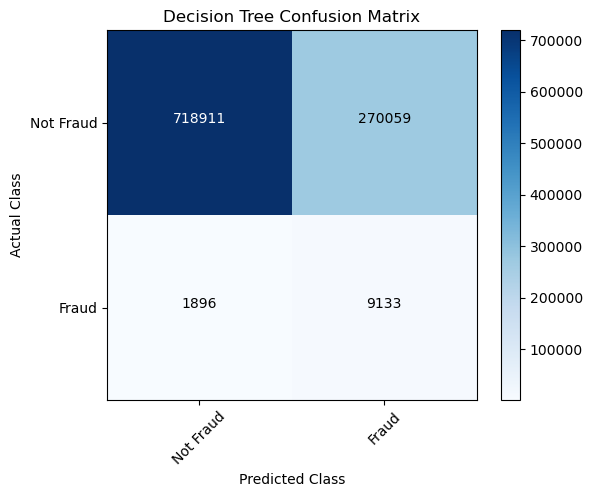

In [28]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y, y_pred_full)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")
plt.show()

## Support Vector Machine Model

In [29]:
print("Evaluating Support Vector Machine Model...")
X_scaled_reduced = np.delete(X_scaled, [24, 30], axis=1)
print(X_scaled_reduced.shape)
y_pred_svm_full = svm_clf.predict(X_scaled_reduced)
# ==========================================
# 4. FINAL STATUS REPORT
# ==========================================
print("\n" + "="*40)
print("FINAL EVALUATION: FULL IMBALANCED DATASET")
print("="*40)
print(f"Accuracy: {accuracy_score(y, y_pred_svm_full):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_svm_full))
print("\nClassification Report:")
print(classification_report(y, y_pred_svm_full))

Evaluating Support Vector Machine Model...
(999999, 47)

FINAL EVALUATION: FULL IMBALANCED DATASET
Accuracy: 0.5572

Confusion Matrix:
[[546731 442239]
 [   528  10501]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.55      0.71    988970
         1.0       0.02      0.95      0.05     11029

    accuracy                           0.56    999999
   macro avg       0.51      0.75      0.38    999999
weighted avg       0.99      0.56      0.70    999999



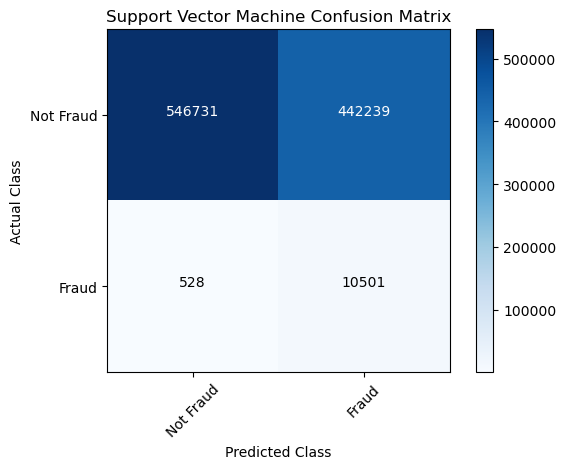

In [30]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y, y_pred_svm_full)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Support Vector Machine Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

## Ensemble Model

In [31]:
y_pred_ensemble_full = ensemble_clf.predict(X_scaled_reduced)

# ==========================================
# 4. FINAL STATUS REPORT
# ==========================================
print("\n" + "="*40)
print("FINAL EVALUATION: FULL IMBALANCED DATASET")
print("="*40)
print(f"Accuracy: {accuracy_score(y, y_pred_ensemble_full):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_ensemble_full))
print("\nClassification Report:")
print(classification_report(y, y_pred_ensemble_full))


FINAL EVALUATION: FULL IMBALANCED DATASET
Accuracy: 0.6082

Confusion Matrix:
[[598006 390964]
 [   877  10152]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.60      0.75    988970
         1.0       0.03      0.92      0.05     11029

    accuracy                           0.61    999999
   macro avg       0.51      0.76      0.40    999999
weighted avg       0.99      0.61      0.75    999999



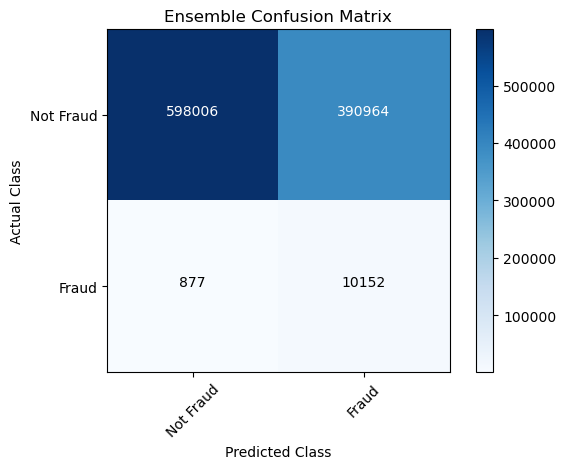

In [32]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y, y_pred_ensemble_full)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Ensemble Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

## Stacking Model

In [33]:
# PREDICT using the existing stacking_model (No retraining)

y_pred_stacking_full = stacking_model.predict(X_scaled_reduced)

# ==========================================
# 4. FINAL STATUS REPORT
# ==========================================
print("\n" + "="*40)
print("FINAL EVALUATION: FULL IMBALANCED DATASET")
print("="*40)
print(f"Accuracy: {accuracy_score(y, y_pred_stacking_full):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_stacking_full))
print("\nClassification Report:")
print(classification_report(y, y_pred_stacking_full))


FINAL EVALUATION: FULL IMBALANCED DATASET
Accuracy: 0.5704

Confusion Matrix:
[[559893 429077]
 [   552  10477]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.57      0.72    988970
         1.0       0.02      0.95      0.05     11029

    accuracy                           0.57    999999
   macro avg       0.51      0.76      0.38    999999
weighted avg       0.99      0.57      0.72    999999



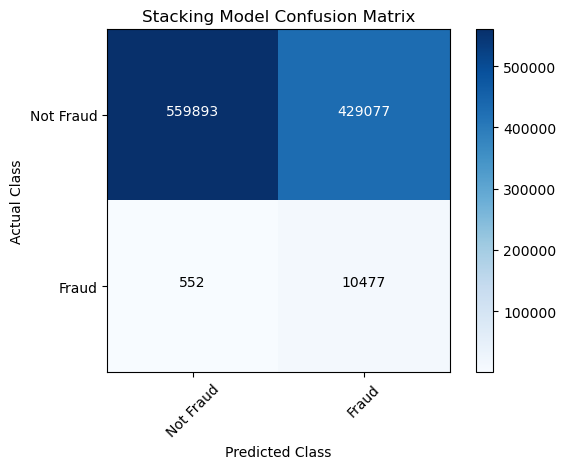

In [34]:
classes = ["Not Fraud", "Fraud"]

# Plot the confusion matrix
mcm = confusion_matrix(y, y_pred_stacking_full)
plt.imshow(mcm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Stacking Model Confusion Matrix")
thresh = mcm.max() / 2.  # Find the midpoint to decide text color (white or black)
for i in range(mcm.shape[0]):
    for j in range(mcm.shape[1]):
        plt.text(j, i, format(mcm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if mcm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()